Initially created tasks:
  Task ID Task Position (x, y)  Urgency  Duration (min)
0      T1             (20, 46)        5            28.0
1      T2             (39, 71)        7            15.0
2      T3              (1, 95)        9            12.0
3      T4              (15, 8)        6            12.0
4      T5             (44, 61)        8            25.0
5      T6              (7, 65)        4            20.0
6      T7             (59, 63)        0            14.0
7      T8             (94, 38)        1            21.0
8      T9              (7, 10)        6            15.0
9     T10             (97, 17)        2            16.0

Time step: 0

Time step: 1

Time step: 2
New dynamic task created: {'Task ID': 'D1', 'Task Position (x, y)': (47, 100), 'Urgency': 3, 'Duration (min)': 12}

Time step: 3

Time step: 4
New dynamic task created: {'Task ID': 'D2', 'Task Position (x, y)': (34, 14), 'Urgency': 1, 'Duration (min)': 15}

Time step: 5

Time step: 6
New dynamic task created: {'Task

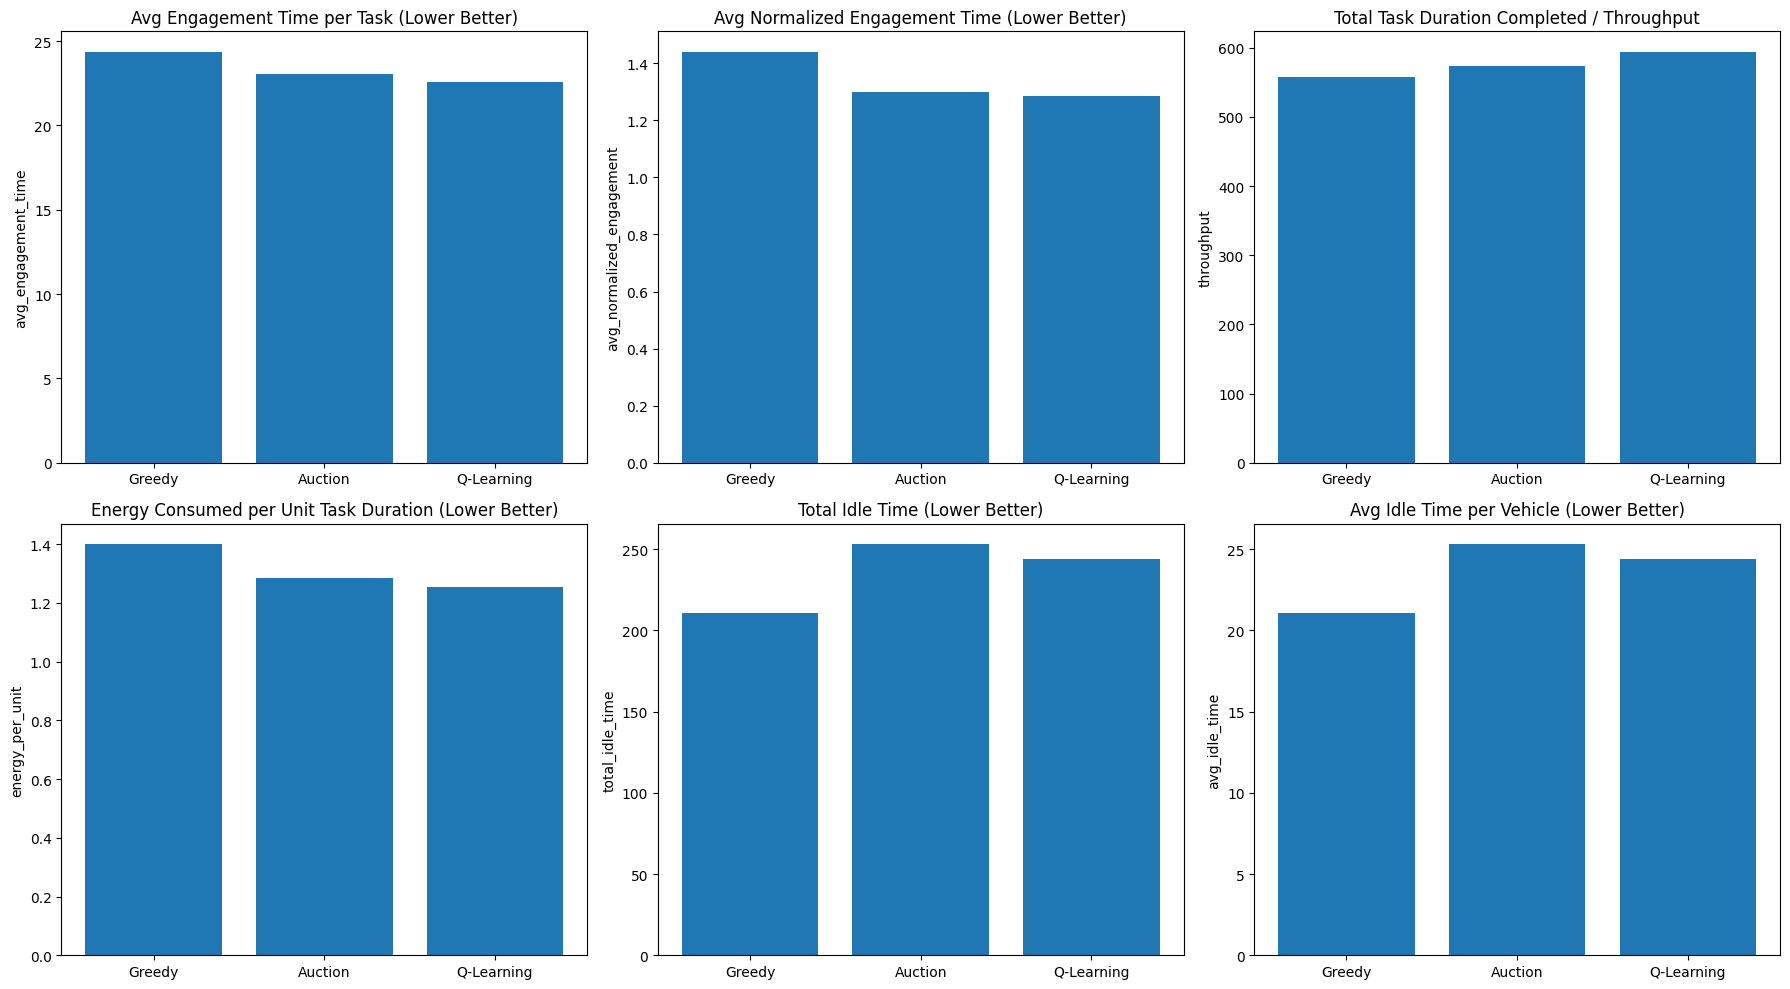

In [1]:
# fleet_ComparisonDynamic.ipynb

import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

import DataGenerationDynamic as dgd

import fleet_greedy_allocationDynamic as ga
import fleet_auction_allocationDynamic as aa
import fleet_qlearning_allocationDynamic as qa


# =========================================================
# Simulation Parameters
# =========================================================

TIME_STEPS = 100
NEW_TASK_PROB = 0.5
URGENCY_INCREMENT = 1


# =========================================================
# Generate Initial Vehicle Data
# =========================================================

vehicles_df = dgd.generate_vehicle_data(10)

vehicles_greedy = vehicles_df.copy()
vehicles_auction = vehicles_df.copy()
vehicles_qlearning = vehicles_df.copy()


# =========================================================
# Add Tracking Columns
# =========================================================

for vehicles in [
    vehicles_greedy,
    vehicles_auction,
    vehicles_qlearning
]:

    vehicles['Busy'] = False

    vehicles['Remaining Duration'] = 0.0

    vehicles["Battery Level (%)"] = (
        vehicles["Battery Level (%)"]
        .astype(float)
    )

    vehicles["Remaining Duration"] = (
        vehicles["Remaining Duration"]
        .astype(float)
    )

    vehicles["Idle Time"] = 0.0


# =========================================================
# Initial Tasks
# =========================================================

initial_tasks = dgd.generate_task_data(num_tasks=10)

print("Initially created tasks:")
print(initial_tasks)


tasks_waiting_greedy = (
    initial_tasks.to_dict('records')
)

tasks_waiting_auction = (
    initial_tasks.to_dict('records')
)

tasks_waiting_qlearning = (
    initial_tasks.to_dict('records')
)


# =========================================================
# Allocation Dictionaries
# =========================================================

allocations_greedy = {}
allocations_auction = {}
allocations_qlearning = {}


# =========================================================
# Engagement Metrics
# =========================================================

engagement_metrics_greedy = []
engagement_metrics_auction = []
engagement_metrics_qlearning = []


task_counter = 1


# =========================================================
# Simulation Loop
# =========================================================

for t in range(TIME_STEPS):

    print(f"\nTime step: {t}")

    # =====================================================
    # Update busy vehicles and idle times
    # =====================================================

    for vehicles in [
        vehicles_greedy,
        vehicles_auction,
        vehicles_qlearning
    ]:

        for idx, vehicle in vehicles.iterrows():

            if vehicle['Busy']:

                new_duration = (
                    vehicle['Remaining Duration'] - 1
                )

                vehicles.at[
                    idx,
                    'Remaining Duration'
                ] = new_duration

                if new_duration <= 0:

                    vehicles.at[idx, 'Busy'] = False

                    vehicles.at[
                        idx,
                        'Remaining Duration'
                    ] = 0

            else:

                vehicles.at[
                    idx,
                    'Idle Time'
                ] = (
                    float(vehicle['Idle Time']) + 1
                )


    # =====================================================
    # Increase urgency for waiting tasks
    # =====================================================

    for task in tasks_waiting_greedy:
        task['Urgency'] += URGENCY_INCREMENT

    for task in tasks_waiting_auction:
        task['Urgency'] += URGENCY_INCREMENT

    for task in tasks_waiting_qlearning:
        task['Urgency'] += URGENCY_INCREMENT


    # =====================================================
    # Dynamic Task Arrival
    # =====================================================

    if random.random() < NEW_TASK_PROB:

        new_task = {

            'Task ID': f"D{task_counter}",

            'Task Position (x, y)': (
                random.randint(0, 100),
                random.randint(0, 100)
            ),

            'Urgency': random.randint(0, 9),

            'Duration (min)': random.randint(10, 30)
        }

        print("New dynamic task created:", new_task)

        task_counter += 1

        tasks_waiting_greedy.append(
            new_task.copy()
        )

        tasks_waiting_auction.append(
            new_task.copy()
        )

        tasks_waiting_qlearning.append(
            new_task.copy()
        )


    # =====================================================
    # Greedy Allocation
    # =====================================================

    if tasks_waiting_greedy:

        tasks_df_greedy = pd.DataFrame(
            tasks_waiting_greedy
        )

        alloc_g, details_g = (
            ga.greedy_allocation(
                vehicles_greedy,
                tasks_df_greedy
            )
        )

        allocations_greedy.update(
            alloc_g
        )

        engagement_metrics_greedy.extend(
            details_g
        )

        allocated_ids = set(
            alloc_g.keys()
        )

        tasks_waiting_greedy = [

            task

            for task in tasks_waiting_greedy

            if task['Task ID']
            not in allocated_ids
        ]


    # =====================================================
    # Auction Allocation
    # =====================================================

    if tasks_waiting_auction:

        tasks_df_auction = pd.DataFrame(
            tasks_waiting_auction
        )

        alloc_a, details_a = (
            aa.auction_allocation(
                vehicles_auction,
                tasks_df_auction
            )
        )

        allocations_auction.update(
            alloc_a
        )

        engagement_metrics_auction.extend(
            details_a
        )

        allocated_ids = set(
            alloc_a.keys()
        )

        tasks_waiting_auction = [

            task

            for task in tasks_waiting_auction

            if task['Task ID']
            not in allocated_ids
        ]


    # =====================================================
    # Q-Learning Allocation
    # =====================================================

    if tasks_waiting_qlearning:

        tasks_df_q = pd.DataFrame(
            tasks_waiting_qlearning
        )

        alloc_q, details_q = (
            qa.qlearning_allocation(
                vehicles_qlearning,
                tasks_df_q
            )
        )

        allocations_qlearning.update(
            alloc_q
        )

        engagement_metrics_qlearning.extend(
            details_q
        )

        allocated_ids = set(
            alloc_q.keys()
        )

        tasks_waiting_qlearning = [

            task

            for task in tasks_waiting_qlearning

            if task['Task ID']
            not in allocated_ids
        ]


# =========================================================
# Final Allocation Output
# =========================================================

print("\nFinal Allocation:")

print("Greedy:", allocations_greedy)

print("Auction:", allocations_auction)

print("Q-Learning:", allocations_qlearning)


# =========================================================
# Remaining Tasks
# =========================================================

print("\nTasks not serviced at the end:")

print("Greedy:", len(tasks_waiting_greedy))

print("Auction:", len(tasks_waiting_auction))

print("Q-Learning:", len(tasks_waiting_qlearning))


# =========================================================
# Compute Metrics
# =========================================================

def compute_metrics(
    engagement_metrics,
    vehicles_df
):

    if not engagement_metrics:
        return {}

    num_tasks = len(engagement_metrics)

    total_engagement_time = sum(
        item["engagement_time"]
        for item in engagement_metrics
    )

    avg_engagement_time = (
        total_engagement_time / num_tasks
    )

    avg_normalized_engagement = sum(
        item["normalized_engagement_time"]
        for item in engagement_metrics
    ) / num_tasks

    total_task_duration = sum(
        item["task_duration"]
        for item in engagement_metrics
    )

    total_energy_consumed = sum(
        item["energy_consumed"]
        for item in engagement_metrics
    )

    energy_per_unit = (

        total_energy_consumed
        / total_task_duration

        if total_task_duration > 0

        else None
    )

    throughput = total_task_duration

    total_idle_time = (
        vehicles_df["Idle Time"].sum()
    )

    avg_idle_time = (
        total_idle_time / len(vehicles_df)
    )

    return {

        "num_tasks": num_tasks,

        "avg_engagement_time":
            avg_engagement_time,

        "avg_normalized_engagement":
            avg_normalized_engagement,

        "energy_per_unit":
            energy_per_unit,

        "throughput":
            throughput,

        "total_idle_time":
            total_idle_time,

        "avg_idle_time":
            avg_idle_time
    }


# =========================================================
# Final Metrics
# =========================================================

metrics_greedy = compute_metrics(
    engagement_metrics_greedy,
    vehicles_greedy
)

metrics_auction = compute_metrics(
    engagement_metrics_auction,
    vehicles_auction
)

metrics_qlearning = compute_metrics(
    engagement_metrics_qlearning,
    vehicles_qlearning
)


print("\nGreedy Metrics:")
print(metrics_greedy)

print("\nAuction Metrics:")
print(metrics_auction)

print("\nQ-Learning Metrics:")
print(metrics_qlearning)


# =========================================================
# Visualization Panel
# =========================================================

methods = [
    "Greedy",
    "Auction",
    "Q-Learning"
]

metrics_labels = [

    "avg_engagement_time",
    "avg_normalized_engagement",
    "throughput",
    "energy_per_unit",
    "total_idle_time",
    "avg_idle_time"
]

titles = [

    "Avg Engagement Time per Task (Lower Better)",

    "Avg Normalized Engagement Time (Lower Better)",

    "Total Task Duration Completed / Throughput",

    "Energy Consumed per Unit Task Duration (Lower Better)",

    "Total Idle Time (Lower Better)",

    "Avg Idle Time per Vehicle (Lower Better)"
]


all_metrics = [

    metrics_greedy,
    metrics_auction,
    metrics_qlearning
]


fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10)
)

axes = axes.flatten()


for i, metric in enumerate(metrics_labels):

    values = [
        all_metrics[0][metric],
        all_metrics[1][metric],
        all_metrics[2][metric]
    ]

    axes[i].bar(
        methods,
        values
    )

    axes[i].set_title(
        titles[i]
    )

    axes[i].set_ylabel(
        metric
    )


plt.tight_layout()

plt.show()


RUN 1/100

RUN 2/100

RUN 3/100

RUN 4/100

RUN 5/100

RUN 6/100

RUN 7/100

RUN 8/100

RUN 9/100

RUN 10/100

RUN 11/100

RUN 12/100

RUN 13/100

RUN 14/100

RUN 15/100

RUN 16/100

RUN 17/100

RUN 18/100

RUN 19/100

RUN 20/100

RUN 21/100

RUN 22/100

RUN 23/100

RUN 24/100

RUN 25/100

RUN 26/100

RUN 27/100

RUN 28/100

RUN 29/100

RUN 30/100

RUN 31/100

RUN 32/100

RUN 33/100

RUN 34/100

RUN 35/100

RUN 36/100

RUN 37/100

RUN 38/100

RUN 39/100

RUN 40/100

RUN 41/100

RUN 42/100

RUN 43/100

RUN 44/100

RUN 45/100

RUN 46/100

RUN 47/100

RUN 48/100

RUN 49/100

RUN 50/100

RUN 51/100

RUN 52/100

RUN 53/100

RUN 54/100

RUN 55/100

RUN 56/100

RUN 57/100

RUN 58/100

RUN 59/100

RUN 60/100

RUN 61/100

RUN 62/100

RUN 63/100

RUN 64/100

RUN 65/100

RUN 66/100

RUN 67/100

RUN 68/100

RUN 69/100

RUN 70/100

RUN 71/100

RUN 72/100

RUN 73/100

RUN 74/100

RUN 75/100

RUN 76/100

RUN 77/100

RUN 78/100

RUN 79/100

RUN 80/100

RUN 81/100

RUN 82/100

RUN 83/100

RUN 84/100



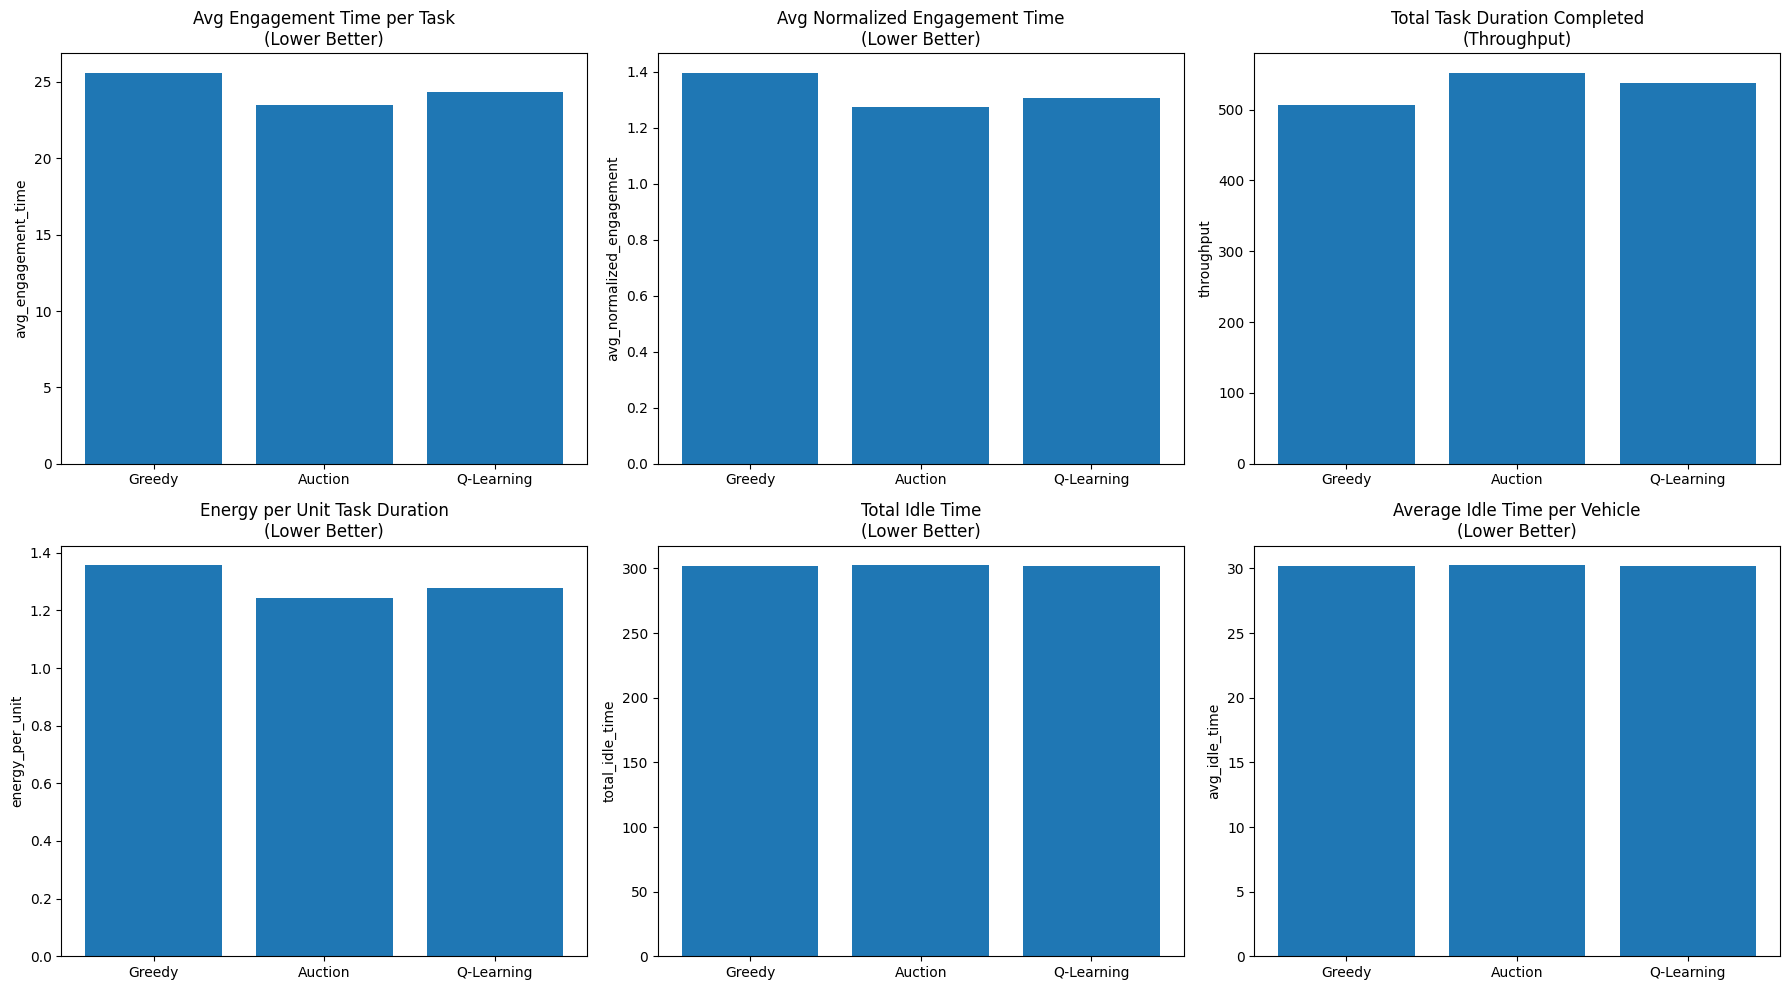

In [2]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

import DataGenerationDynamic as dgd

import fleet_greedy_allocationDynamic as ga
import fleet_auction_allocationDynamic as aa
import fleet_qlearning_allocationDynamic as qa


# =========================================================
# PARAMETERS
# =========================================================

TIME_STEPS = 100
NEW_TASK_PROB = 0.5
URGENCY_INCREMENT = 1

NUM_RUNS = 100


# =========================================================
# METRIC STORAGE
# =========================================================

all_results = {

    "Greedy": [],
    "Auction": [],
    "Q-Learning": []
}


# =========================================================
# METRIC FUNCTION
# =========================================================

def compute_metrics(
    engagement_metrics,
    vehicles_df
):

    if not engagement_metrics:
        return None

    num_tasks = len(engagement_metrics)

    total_engagement_time = sum(
        item["engagement_time"]
        for item in engagement_metrics
    )

    avg_engagement_time = (
        total_engagement_time / num_tasks
    )

    avg_normalized_engagement = sum(
        item["normalized_engagement_time"]
        for item in engagement_metrics
    ) / num_tasks

    total_task_duration = sum(
        item["task_duration"]
        for item in engagement_metrics
    )

    total_energy_consumed = sum(
        item["energy_consumed"]
        for item in engagement_metrics
    )

    energy_per_unit = (

        total_energy_consumed
        / total_task_duration

        if total_task_duration > 0
        else 0
    )

    throughput = total_task_duration

    total_idle_time = (
        vehicles_df["Idle Time"].sum()
    )

    avg_idle_time = (
        total_idle_time / len(vehicles_df)
    )

    return {

        "num_tasks": num_tasks,

        "avg_engagement_time":
            avg_engagement_time,

        "avg_normalized_engagement":
            avg_normalized_engagement,

        "energy_per_unit":
            energy_per_unit,

        "throughput":
            throughput,

        "total_idle_time":
            total_idle_time,

        "avg_idle_time":
            avg_idle_time
    }


# =========================================================
# RUN MULTIPLE SEEDED EXPERIMENTS
# =========================================================

for seed in range(NUM_RUNS):

    print("\n=================================================")
    print(f"RUN {seed + 1}/{NUM_RUNS}")
    print("=================================================")

    # -----------------------------------------------------
    # FIX RANDOMNESS
    # -----------------------------------------------------

    random.seed(seed)
    np.random.seed(seed)

    # -----------------------------------------------------
    # Generate SAME initial environment
    # -----------------------------------------------------

    vehicles_df = dgd.generate_vehicle_data(10)

    vehicles_greedy = vehicles_df.copy()
    vehicles_auction = vehicles_df.copy()
    vehicles_qlearning = vehicles_df.copy()

    # -----------------------------------------------------
    # Add tracking columns
    # -----------------------------------------------------

    for vehicles in [
        vehicles_greedy,
        vehicles_auction,
        vehicles_qlearning
    ]:

        vehicles['Busy'] = False

        vehicles['Remaining Duration'] = 0

        vehicles["Battery Level (%)"] = (
            vehicles["Battery Level (%)"]
            .astype(float)
        )

        vehicles["Remaining Duration"] = (
            vehicles["Remaining Duration"]
            .astype(float)
        )

        vehicles["Idle Time"] = 0.0

    # -----------------------------------------------------
    # Initial tasks
    # -----------------------------------------------------

    initial_tasks = dgd.generate_task_data(10)

    tasks_waiting_greedy = (
        initial_tasks.to_dict('records')
    )

    tasks_waiting_auction = (
        initial_tasks.to_dict('records')
    )

    tasks_waiting_qlearning = (
        initial_tasks.to_dict('records')
    )

    # -----------------------------------------------------
    # Allocation storage
    # -----------------------------------------------------

    allocations_greedy = {}
    allocations_auction = {}
    allocations_qlearning = {}

    engagement_metrics_greedy = []
    engagement_metrics_auction = []
    engagement_metrics_qlearning = []

    task_counter = 1

    # =====================================================
    # SIMULATION LOOP
    # =====================================================

    for t in range(TIME_STEPS):

        # -------------------------------------------------
        # Update vehicles
        # -------------------------------------------------

        for vehicles in [
            vehicles_greedy,
            vehicles_auction,
            vehicles_qlearning
        ]:

            for idx, vehicle in vehicles.iterrows():

                if vehicle['Busy']:

                    new_duration = (
                        vehicle['Remaining Duration'] - 1
                    )

                    vehicles.at[
                        idx,
                        'Remaining Duration'
                    ] = new_duration

                    if new_duration <= 0:

                        vehicles.at[
                            idx,
                            'Busy'
                        ] = False

                        vehicles.at[
                            idx,
                            'Remaining Duration'
                        ] = 0

                else:

                    vehicles.at[
                        idx,
                        'Idle Time'
                    ] += 1

        # -------------------------------------------------
        # Increase urgency
        # -------------------------------------------------

        for task in tasks_waiting_greedy:
            task['Urgency'] += URGENCY_INCREMENT

        for task in tasks_waiting_auction:
            task['Urgency'] += URGENCY_INCREMENT

        for task in tasks_waiting_qlearning:
            task['Urgency'] += URGENCY_INCREMENT

        # -------------------------------------------------
        # Dynamic task arrivals
        # -------------------------------------------------

        if random.random() < NEW_TASK_PROB:

            new_task = {

                'Task ID': f"D{task_counter}",

                'Task Position (x, y)': (
                    random.randint(0, 100),
                    random.randint(0, 100)
                ),

                'Urgency':
                    random.randint(0, 9),

                'Duration (min)':
                    random.randint(10, 30)
            }

            task_counter += 1

            tasks_waiting_greedy.append(
                new_task.copy()
            )

            tasks_waiting_auction.append(
                new_task.copy()
            )

            tasks_waiting_qlearning.append(
                new_task.copy()
            )

        # -------------------------------------------------
        # GREEDY
        # -------------------------------------------------

        if tasks_waiting_greedy:

            tasks_df = pd.DataFrame(
                tasks_waiting_greedy
            )

            alloc, details = (
                ga.greedy_allocation(
                    vehicles_greedy,
                    tasks_df
                )
            )

            allocations_greedy.update(
                alloc
            )

            engagement_metrics_greedy.extend(
                details
            )

            allocated_ids = set(
                alloc.keys()
            )

            tasks_waiting_greedy = [

                task

                for task in tasks_waiting_greedy

                if task['Task ID']
                not in allocated_ids
            ]

        # -------------------------------------------------
        # AUCTION
        # -------------------------------------------------

        if tasks_waiting_auction:

            tasks_df = pd.DataFrame(
                tasks_waiting_auction
            )

            alloc, details = (
                aa.auction_allocation(
                    vehicles_auction,
                    tasks_df
                )
            )

            allocations_auction.update(
                alloc
            )

            engagement_metrics_auction.extend(
                details
            )

            allocated_ids = set(
                alloc.keys()
            )

            tasks_waiting_auction = [

                task

                for task in tasks_waiting_auction

                if task['Task ID']
                not in allocated_ids
            ]

        # -------------------------------------------------
        # Q-LEARNING
        # -------------------------------------------------

        if tasks_waiting_qlearning:

            tasks_df = pd.DataFrame(
                tasks_waiting_qlearning
            )

            alloc, details = (
                qa.qlearning_allocation(
                    vehicles_qlearning,
                    tasks_df
                )
            )

            allocations_qlearning.update(
                alloc
            )

            engagement_metrics_qlearning.extend(
                details
            )

            allocated_ids = set(
                alloc.keys()
            )

            tasks_waiting_qlearning = [

                task

                for task in tasks_waiting_qlearning

                if task['Task ID']
                not in allocated_ids
            ]

    # =====================================================
    # STORE RUN RESULTS
    # =====================================================

    metrics_greedy = compute_metrics(
        engagement_metrics_greedy,
        vehicles_greedy
    )

    metrics_auction = compute_metrics(
        engagement_metrics_auction,
        vehicles_auction
    )

    metrics_qlearning = compute_metrics(
        engagement_metrics_qlearning,
        vehicles_qlearning
    )

    all_results["Greedy"].append(
        metrics_greedy
    )

    all_results["Auction"].append(
        metrics_auction
    )

    all_results["Q-Learning"].append(
        metrics_qlearning
    )


# =========================================================
# AVERAGE RESULTS
# =========================================================

metric_keys = [

    "num_tasks",
    "avg_engagement_time",
    "avg_normalized_engagement",
    "energy_per_unit",
    "throughput",
    "total_idle_time",
    "avg_idle_time"
]

average_results = {}

for method in all_results:

    average_results[method] = {}

    for key in metric_keys:

        values = [

            run[key]

            for run in all_results[method]

            if run is not None
        ]

        average_results[method][key] = np.mean(values)


# =========================================================
# PRINT FINAL AVERAGES
# =========================================================

print("\n=================================================")
print("AVERAGED RESULTS ACROSS RUNS")
print("=================================================")

for method in average_results:

    print(f"\n{method}")

    for metric, value in average_results[
        method
    ].items():

        print(f"{metric}: {value:.4f}")


# =========================================================
# PLOTS
# =========================================================

methods = [
    "Greedy",
    "Auction",
    "Q-Learning"
]

metrics_labels = [

    "avg_engagement_time",
    "avg_normalized_engagement",
    "throughput",
    "energy_per_unit",
    "total_idle_time",
    "avg_idle_time"
]

titles = [

    "Avg Engagement Time per Task\n(Lower Better)",

    "Avg Normalized Engagement Time\n(Lower Better)",

    "Total Task Duration Completed\n(Throughput)",

    "Energy per Unit Task Duration\n(Lower Better)",

    "Total Idle Time\n(Lower Better)",

    "Average Idle Time per Vehicle\n(Lower Better)"
]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10)
)

axes = axes.flatten()

for i, metric in enumerate(metrics_labels):

    values = [

        average_results["Greedy"][metric],

        average_results["Auction"][metric],

        average_results["Q-Learning"][metric]
    ]

    axes[i].bar(
        methods,
        values
    )

    axes[i].set_title(
        titles[i]
    )

    axes[i].set_ylabel(metric)

plt.tight_layout()

plt.show()


RUN 1/1000

RUN 2/1000

RUN 3/1000

RUN 4/1000

RUN 5/1000

RUN 6/1000

RUN 7/1000

RUN 8/1000

RUN 9/1000

RUN 10/1000

RUN 11/1000

RUN 12/1000

RUN 13/1000

RUN 14/1000

RUN 15/1000

RUN 16/1000

RUN 17/1000

RUN 18/1000

RUN 19/1000

RUN 20/1000

RUN 21/1000

RUN 22/1000

RUN 23/1000

RUN 24/1000

RUN 25/1000

RUN 26/1000

RUN 27/1000

RUN 28/1000

RUN 29/1000

RUN 30/1000

RUN 31/1000

RUN 32/1000

RUN 33/1000

RUN 34/1000

RUN 35/1000

RUN 36/1000

RUN 37/1000

RUN 38/1000

RUN 39/1000

RUN 40/1000

RUN 41/1000

RUN 42/1000

RUN 43/1000

RUN 44/1000

RUN 45/1000

RUN 46/1000

RUN 47/1000

RUN 48/1000

RUN 49/1000

RUN 50/1000

RUN 51/1000

RUN 52/1000

RUN 53/1000

RUN 54/1000

RUN 55/1000

RUN 56/1000

RUN 57/1000

RUN 58/1000

RUN 59/1000

RUN 60/1000

RUN 61/1000

RUN 62/1000

RUN 63/1000

RUN 64/1000

RUN 65/1000

RUN 66/1000

RUN 67/1000

RUN 68/1000

RUN 69/1000

RUN 70/1000

RUN 71/1000

RUN 72/1000

RUN 73/1000

RUN 74/1000

RUN 75/1000

RUN 76/1000

RUN 77/1000

RUN 78/

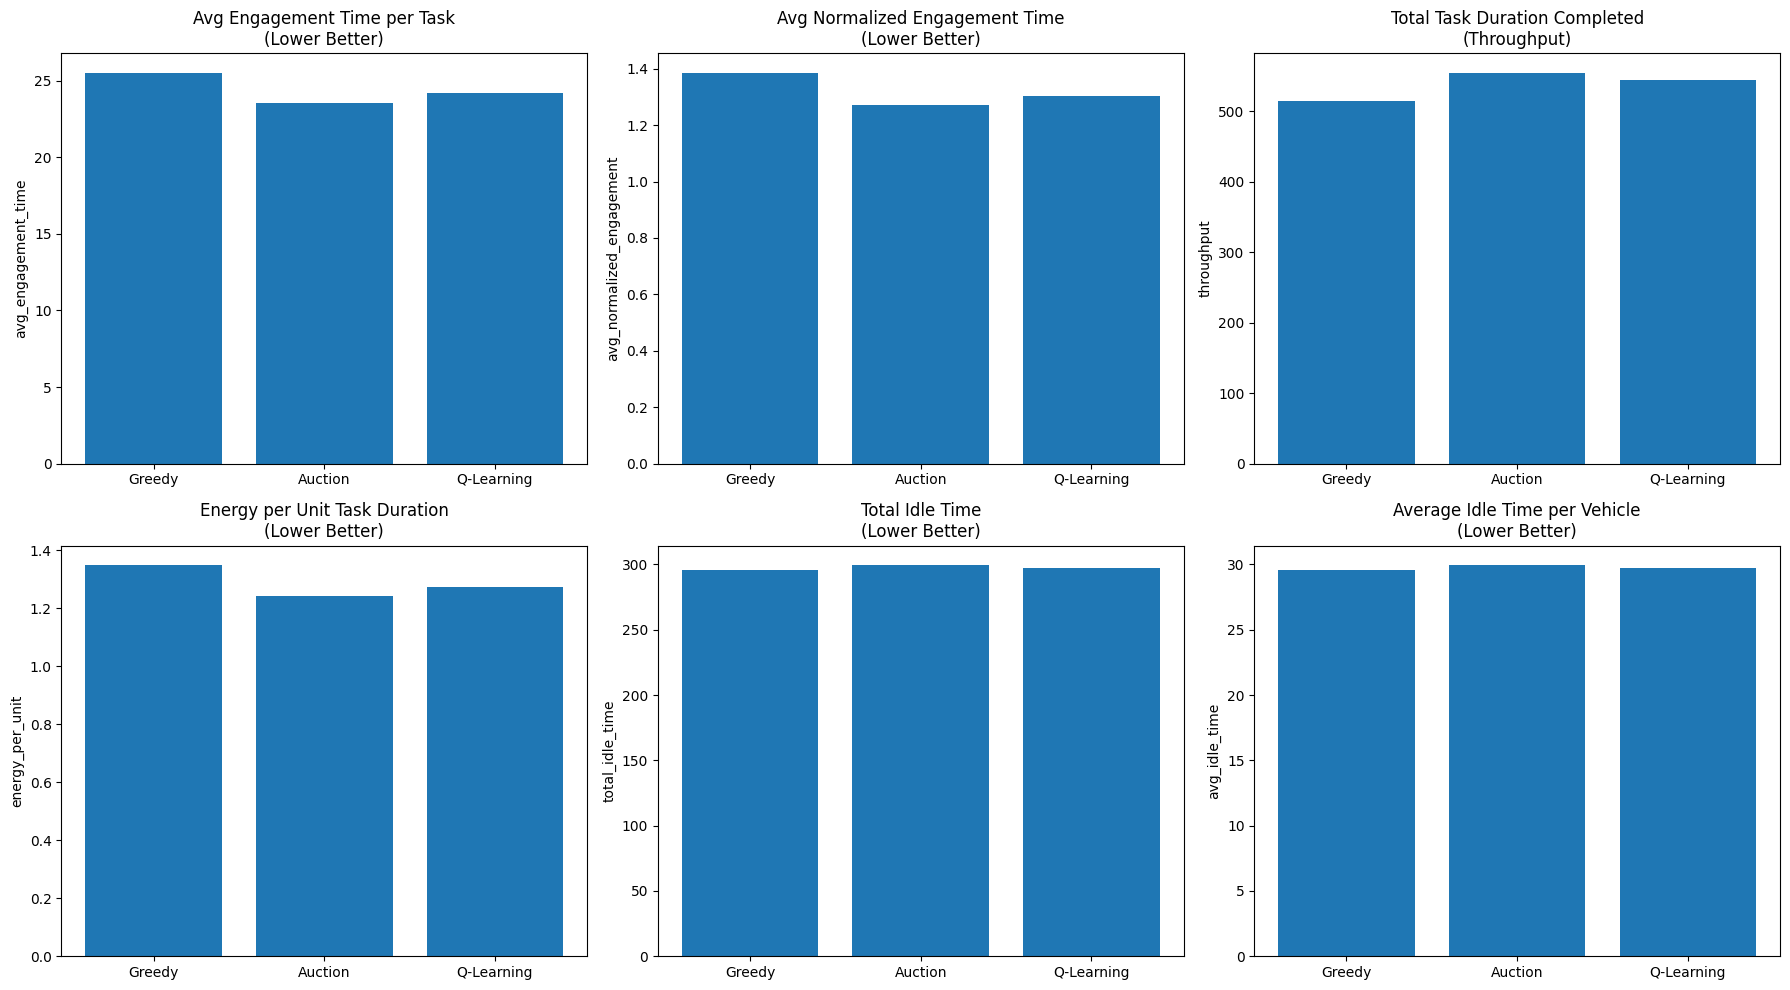

In [3]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

import DataGenerationDynamic as dgd

import fleet_greedy_allocationDynamic as ga
import fleet_auction_allocationDynamic as aa
import fleet_qlearning_allocationDynamic as qa


# =========================================================
# PARAMETERS
# =========================================================

TIME_STEPS = 100
NEW_TASK_PROB = 0.5
URGENCY_INCREMENT = 1

NUM_RUNS = 1000


# =========================================================
# METRIC STORAGE
# =========================================================

all_results = {

    "Greedy": [],
    "Auction": [],
    "Q-Learning": []
}


# =========================================================
# METRIC FUNCTION
# =========================================================

def compute_metrics(
    engagement_metrics,
    vehicles_df
):

    if not engagement_metrics:
        return None

    num_tasks = len(engagement_metrics)

    total_engagement_time = sum(
        item["engagement_time"]
        for item in engagement_metrics
    )

    avg_engagement_time = (
        total_engagement_time / num_tasks
    )

    avg_normalized_engagement = sum(
        item["normalized_engagement_time"]
        for item in engagement_metrics
    ) / num_tasks

    total_task_duration = sum(
        item["task_duration"]
        for item in engagement_metrics
    )

    total_energy_consumed = sum(
        item["energy_consumed"]
        for item in engagement_metrics
    )

    energy_per_unit = (

        total_energy_consumed
        / total_task_duration

        if total_task_duration > 0
        else 0
    )

    throughput = total_task_duration

    total_idle_time = (
        vehicles_df["Idle Time"].sum()
    )

    avg_idle_time = (
        total_idle_time / len(vehicles_df)
    )

    return {

        "num_tasks": num_tasks,

        "avg_engagement_time":
            avg_engagement_time,

        "avg_normalized_engagement":
            avg_normalized_engagement,

        "energy_per_unit":
            energy_per_unit,

        "throughput":
            throughput,

        "total_idle_time":
            total_idle_time,

        "avg_idle_time":
            avg_idle_time
    }


# =========================================================
# RUN MULTIPLE SEEDED EXPERIMENTS
# =========================================================

for seed in range(NUM_RUNS):

    print("\n=================================================")
    print(f"RUN {seed + 1}/{NUM_RUNS}")
    print("=================================================")

    # -----------------------------------------------------
    # FIX RANDOMNESS
    # -----------------------------------------------------

    random.seed(seed)
    np.random.seed(seed)

    # -----------------------------------------------------
    # Generate SAME initial environment
    # -----------------------------------------------------

    vehicles_df = dgd.generate_vehicle_data(10)

    vehicles_greedy = vehicles_df.copy()
    vehicles_auction = vehicles_df.copy()
    vehicles_qlearning = vehicles_df.copy()

    # -----------------------------------------------------
    # Add tracking columns
    # -----------------------------------------------------

    for vehicles in [
        vehicles_greedy,
        vehicles_auction,
        vehicles_qlearning
    ]:

        vehicles['Busy'] = False

        vehicles['Remaining Duration'] = 0

        vehicles["Battery Level (%)"] = (
            vehicles["Battery Level (%)"]
            .astype(float)
        )

        vehicles["Remaining Duration"] = (
            vehicles["Remaining Duration"]
            .astype(float)
        )

        vehicles["Idle Time"] = 0.0

    # -----------------------------------------------------
    # Initial tasks
    # -----------------------------------------------------

    initial_tasks = dgd.generate_task_data(10)

    tasks_waiting_greedy = (
        initial_tasks.to_dict('records')
    )

    tasks_waiting_auction = (
        initial_tasks.to_dict('records')
    )

    tasks_waiting_qlearning = (
        initial_tasks.to_dict('records')
    )

    # -----------------------------------------------------
    # Allocation storage
    # -----------------------------------------------------

    allocations_greedy = {}
    allocations_auction = {}
    allocations_qlearning = {}

    engagement_metrics_greedy = []
    engagement_metrics_auction = []
    engagement_metrics_qlearning = []

    task_counter = 1

    # =====================================================
    # SIMULATION LOOP
    # =====================================================

    for t in range(TIME_STEPS):

        # -------------------------------------------------
        # Update vehicles
        # -------------------------------------------------

        for vehicles in [
            vehicles_greedy,
            vehicles_auction,
            vehicles_qlearning
        ]:

            for idx, vehicle in vehicles.iterrows():

                if vehicle['Busy']:

                    new_duration = (
                        vehicle['Remaining Duration'] - 1
                    )

                    vehicles.at[
                        idx,
                        'Remaining Duration'
                    ] = new_duration

                    if new_duration <= 0:

                        vehicles.at[
                            idx,
                            'Busy'
                        ] = False

                        vehicles.at[
                            idx,
                            'Remaining Duration'
                        ] = 0

                else:

                    vehicles.at[
                        idx,
                        'Idle Time'
                    ] += 1

        # -------------------------------------------------
        # Increase urgency
        # -------------------------------------------------

        for task in tasks_waiting_greedy:
            task['Urgency'] += URGENCY_INCREMENT

        for task in tasks_waiting_auction:
            task['Urgency'] += URGENCY_INCREMENT

        for task in tasks_waiting_qlearning:
            task['Urgency'] += URGENCY_INCREMENT

        # -------------------------------------------------
        # Dynamic task arrivals
        # -------------------------------------------------

        if random.random() < NEW_TASK_PROB:

            new_task = {

                'Task ID': f"D{task_counter}",

                'Task Position (x, y)': (
                    random.randint(0, 100),
                    random.randint(0, 100)
                ),

                'Urgency':
                    random.randint(0, 9),

                'Duration (min)':
                    random.randint(10, 30)
            }

            task_counter += 1

            tasks_waiting_greedy.append(
                new_task.copy()
            )

            tasks_waiting_auction.append(
                new_task.copy()
            )

            tasks_waiting_qlearning.append(
                new_task.copy()
            )

        # -------------------------------------------------
        # GREEDY
        # -------------------------------------------------

        if tasks_waiting_greedy:

            tasks_df = pd.DataFrame(
                tasks_waiting_greedy
            )

            alloc, details = (
                ga.greedy_allocation(
                    vehicles_greedy,
                    tasks_df
                )
            )

            allocations_greedy.update(
                alloc
            )

            engagement_metrics_greedy.extend(
                details
            )

            allocated_ids = set(
                alloc.keys()
            )

            tasks_waiting_greedy = [

                task

                for task in tasks_waiting_greedy

                if task['Task ID']
                not in allocated_ids
            ]

        # -------------------------------------------------
        # AUCTION
        # -------------------------------------------------

        if tasks_waiting_auction:

            tasks_df = pd.DataFrame(
                tasks_waiting_auction
            )

            alloc, details = (
                aa.auction_allocation(
                    vehicles_auction,
                    tasks_df
                )
            )

            allocations_auction.update(
                alloc
            )

            engagement_metrics_auction.extend(
                details
            )

            allocated_ids = set(
                alloc.keys()
            )

            tasks_waiting_auction = [

                task

                for task in tasks_waiting_auction

                if task['Task ID']
                not in allocated_ids
            ]

        # -------------------------------------------------
        # Q-LEARNING
        # -------------------------------------------------

        if tasks_waiting_qlearning:

            tasks_df = pd.DataFrame(
                tasks_waiting_qlearning
            )

            alloc, details = (
                qa.qlearning_allocation(
                    vehicles_qlearning,
                    tasks_df
                )
            )

            allocations_qlearning.update(
                alloc
            )

            engagement_metrics_qlearning.extend(
                details
            )

            allocated_ids = set(
                alloc.keys()
            )

            tasks_waiting_qlearning = [

                task

                for task in tasks_waiting_qlearning

                if task['Task ID']
                not in allocated_ids
            ]

    # =====================================================
    # STORE RUN RESULTS
    # =====================================================

    metrics_greedy = compute_metrics(
        engagement_metrics_greedy,
        vehicles_greedy
    )

    metrics_auction = compute_metrics(
        engagement_metrics_auction,
        vehicles_auction
    )

    metrics_qlearning = compute_metrics(
        engagement_metrics_qlearning,
        vehicles_qlearning
    )

    all_results["Greedy"].append(
        metrics_greedy
    )

    all_results["Auction"].append(
        metrics_auction
    )

    all_results["Q-Learning"].append(
        metrics_qlearning
    )


# =========================================================
# AVERAGE RESULTS
# =========================================================

metric_keys = [

    "num_tasks",
    "avg_engagement_time",
    "avg_normalized_engagement",
    "energy_per_unit",
    "throughput",
    "total_idle_time",
    "avg_idle_time"
]

average_results = {}

for method in all_results:

    average_results[method] = {}

    for key in metric_keys:

        values = [

            run[key]

            for run in all_results[method]

            if run is not None
        ]

        average_results[method][key] = np.mean(values)


# =========================================================
# PRINT FINAL AVERAGES
# =========================================================

print("\n=================================================")
print("AVERAGED RESULTS ACROSS RUNS")
print("=================================================")

for method in average_results:

    print(f"\n{method}")

    for metric, value in average_results[
        method
    ].items():

        print(f"{metric}: {value:.4f}")


# =========================================================
# PLOTS
# =========================================================

methods = [
    "Greedy",
    "Auction",
    "Q-Learning"
]

metrics_labels = [

    "avg_engagement_time",
    "avg_normalized_engagement",
    "throughput",
    "energy_per_unit",
    "total_idle_time",
    "avg_idle_time"
]

titles = [

    "Avg Engagement Time per Task\n(Lower Better)",

    "Avg Normalized Engagement Time\n(Lower Better)",

    "Total Task Duration Completed\n(Throughput)",

    "Energy per Unit Task Duration\n(Lower Better)",

    "Total Idle Time\n(Lower Better)",

    "Average Idle Time per Vehicle\n(Lower Better)"
]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10)
)

axes = axes.flatten()

for i, metric in enumerate(metrics_labels):

    values = [

        average_results["Greedy"][metric],

        average_results["Auction"][metric],

        average_results["Q-Learning"][metric]
    ]

    axes[i].bar(
        methods,
        values
    )

    axes[i].set_title(
        titles[i]
    )

    axes[i].set_ylabel(metric)

plt.tight_layout()

plt.show()